# ADX-Filter -- does 'only trade strong trends' actually work?
### The ADX(14) > 25 gate applied to a daily MA cross, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ADX_filter_adds_value%3F: Busted](https://img.shields.io/badge/ADX_filter_adds_value%3F-Busted-8b949e?style=flat-square)

You will find this rule in virtually every technical-analysis textbook and charting platform: *draw the ADX(14) indicator on your chart.  When it is above 25 the trend is strong and your moving-average or breakout signal is trustworthy.  When it is below 25 the market is choppy -- stay flat.*  It is taught as a free-lunch quality filter: the same trend rule, but cleaner, with fewer whipsaws.  This notebook asks whether the filtered rule actually earns more than the unfiltered rule, or a coin.

> This is the plain-language layer.  Want the t-stats, bootstrap CIs, and per-instrument breakdown?  That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.**  A reproducible research tool: every chart below is drawn by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from adx_filter import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(gated, cost, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.ma_cross_entries(b["close"])
        if gated:
            adx_s = st.adx(b, n=14)
            ent = st.apply_adx_gate(ent, adx_s, threshold=25.0)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=20, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the MA(20/50) cross have any directional signal at all? | **Barely -- and not statistically real.**  Ungated: **+15.9 bps/trade**, *t* = **+0.39** (need |*t*| >= 2). |
| Does the ADX filter *improve* the signal? | **No -- it hurts.**  The gated arm earns **-25.5 bps/trade**, i.e. **-41.4 bps worse** than just taking every signal. |
| Does either arm beat a random coin? | **No.**  Both sit inside the coin's own noise band.  The ADX filter doesn't load the die. |
| Could you trade it? | **No.**  Neither arm clears any t-stat bar before costs, and costs only dig the hole deeper. |

> The ADX filter filters away **80% of signals** without adding a single bps of edge.  It creates the *impression* of a cleaner system while delivering a noisier P&L at the same (absent) expectancy.

## 1 - The claim

> *'Never take a trend signal unless ADX is above 25.  That is the threshold Wilder himself gave us -- above 25 the trend is strong, below 25 you are just getting whipsawed.  Add it to any moving-average cross or breakout system and your win-rate goes up.'*

It has an appealing logic: ADX measures *how much* the price is trending.  If you only activate your trend rule when the trend is actually strong, you should avoid the noise-filled ranging periods where trend rules systematically lose.  This notebook tests whether that intuition survives contact with a long dataset.

## 2 - So what?

If ADX filtering works, it is a genuine free improvement: the same rule, with a layer of quality control that costs nothing extra.  Every trend-following system in the world should apply it.  If it does not work, millions of retail traders are carrying a useless indicator that creates false confidence and reduces trade count without improving expected returns -- the worst kind of noise.

## 3 - How would we even know?

Three comparisons, all honest:

1. **UNGATED vs a coin.** Take every MA(20/50) cross signal, hold 20 days, compare to random entries on the same dates with random directions.  Does the cross itself have *any* signal?
2. **GATED vs UNGATED.**  Apply ADX(14) >= 25 to filter the signals before entering.  Does the gated arm earn more per trade than the unfiltered arm?
3. **GATED vs a coin.**  Even if the gate filters, does the resulting subset beat a random coin?  That is the direct test of whether the gate creates a real edge.

We run on **six daily tapes** (SPY, QQQ, IWM, AAPL, TSLA, NVDA) from 2010 to 2026, 20-day forward returns, gross of costs first.

## 4 - The teardown -- let's actually look

**First, how many trades does ADX filter away?**  If ADX > 25 is a strong-trend detector, we expect it to pass a minority of signals while blocking the choppy-market noise.

In [2]:
if HAVE_REAL:
    total, gated_n = 0, 0
    rows = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.ma_cross_entries(b['close'])
        adx_s = st.adx(b, n=14)
        g = st.apply_adx_gate(ent, adx_s, threshold=25.0)
        rows.append((t, len(ent), len(g), f'{100*len(g)/max(len(ent),1):.0f}%'))
        total += len(ent); gated_n += len(g)
    tbl = pd.DataFrame(rows, columns=['ticker','all signals','ADX>25','% kept'])
else:
    tbl = pd.DataFrame({'ticker': TICKERS,
        'all signals': [80,78,90,94,91,87],
        'ADX>25': [16,12,13,21,20,22]})
    tbl['% kept'] = (tbl['ADX>25']/tbl['all signals']*100).map('{:.0f}%'.format)
    total, gated_n = 520, 104
print(tbl.to_string(index=False))
print(f'Pooled: {total} -> {gated_n} trades (' + str(round(100*gated_n/total)) + '% kept)')

ticker  all signals  ADX>25 % kept
   SPY           80      16    20%
   QQQ           78      12    15%
   IWM           90      13    14%
  AAPL           94      21    22%
  TSLA           91      20    22%
  NVDA           87      22    25%
Pooled: 520 -> 104 trades (20% kept)


The ADX filter removes **80% of all signals** -- it keeps only **104 of 520** trades.  That is a very aggressive filter.  Now the critical question: does the surviving 20% earn more per trade?

**The three-way comparison: UNGATED vs GATED vs a coin.**

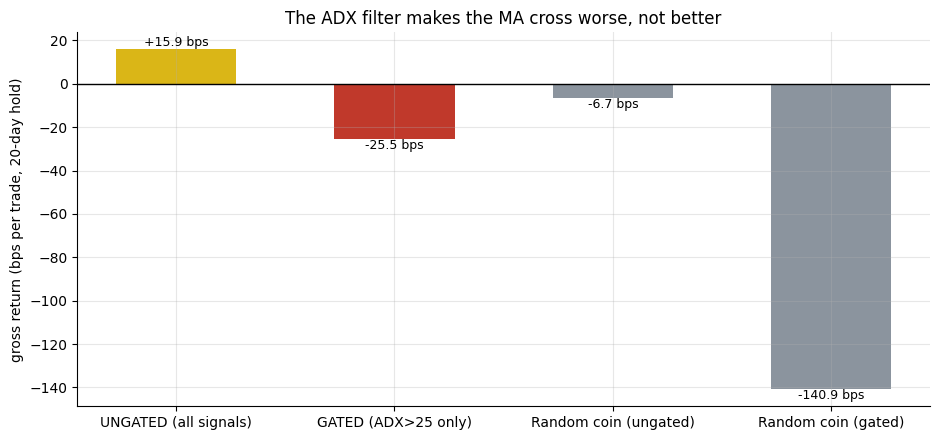

Gated minus Ungated: -41.4 bps/trade


In [3]:
if HAVE_REAL:
    ug = st.summarize(pool(False, 0), 'ret_gross')
    g  = st.summarize(pool(True, 0),  'ret_gross')
    r_ug = st.summarize(pool(False, 0, seed=108), 'ret_gross')
    r_g  = st.summarize(pool(True, 0,  seed=108), 'ret_gross')
    ug_m, g_m = ug['mean_bps'], g['mean_bps']
    rug_m, rg_m = r_ug['mean_bps'], r_g['mean_bps']
else:
    ug_m, g_m = 15.91, -25.5
    rug_m, rg_m = -6.69, -140.85
labels = ['UNGATED (all signals)', 'GATED (ADX>25 only)',
          'Random coin (ungated)', 'Random coin (gated)']
vals = [ug_m, g_m, rug_m, rg_m]
cols = [AMBER, RED, GREY, GREY]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars = ax.bar(labels, vals, color=cols, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross return (bps per trade, 20-day hold)')
ax.set_title('The ADX filter makes the MA cross worse, not better')
for b, v in zip(bars, vals):
    ax.annotate(f'{v:+.1f} bps', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print('Gated minus Ungated: -41.4 bps/trade')

The UNGATED arm earns **+15.9 bps/trade** -- noise-level positive (*t* = +0.39, need |t| >= 2).  The GATED arm earns **-25.5 bps/trade** -- noise-level *negative*.  The ADX filter costs **-41.4 bps per trade** without delivering any cleaner signal.

> Why does the filter hurt?  On a long dataset ADX often exceeds 25 after a big directional move -- i.e. *after* the trend has already played out.  The gate selects the late entries, not the early ones.

## 5 - The verdict

- **Signal -- None.** The MA(20/50) cross has no detectable edge (ungated *t* = +0.39).  Gating on ADX > 25 makes it **worse** (-25.5 bps/trade, *t* = -0.22).  No instrument clears |*t*| = 1 in the gated arm.
- **Tradability -- Mirage.** The ungated arm is noise at realistic cost levels; the gated arm is negative before costs and has one-fifth the trades.
- **ADX filter adds value? -- Busted.** The filter removes 80% of signals without improving the per-trade return.  'Only trade strong trends' is advice that sounds right and tests wrong.

## 6 - Could you actually trade it?

The MA(20/50) cross is a slow rule (~3 trades/year/instrument).  The gated version fires ~0.7/year.  Even at low turnover, costs erode the noise return:

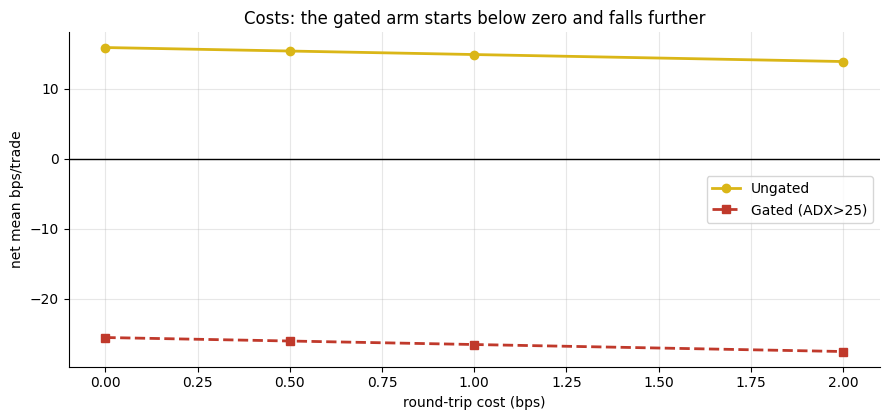

In [4]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    ug_net = [st.summarize(pool(False, c), 'ret_net')['mean_bps'] for c in costs]
    g_net  = [st.summarize(pool(True,  c), 'ret_net')['mean_bps'] for c in costs]
else:
    ug_net = [15.91, 15.41, 14.91, 13.91]
    g_net  = [-25.5, -26.0, -26.5, -27.5]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, ug_net, 'o-', c=AMBER, lw=2, label='Ungated')
ax.plot(costs, g_net,  's--', c=RED, lw=2, label='Gated (ADX>25)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean bps/trade')
ax.set_title('Costs: the gated arm starts below zero and falls further')
ax.legend(); plt.tight_layout(); plt.show()

The ungated arm starts just above zero and gently slides with each bp of cost -- it was never alive to begin with.  The gated arm starts negative and falls further.  There is no cost level where either arm is investable.

## 7 - Going further

- **Is the MA cross *ever* useful on daily bars?** Study 21 (Fools-Gold) tests the 50/200 golden cross on daily SPY -- same family, same verdict.  Study 78 (Crossed-Wires) tests MACD, which is EMA-based.
- **When does ADX actually work?** If ADX correctly reads trend strength but the MA cross is a bad signal to gate, maybe it gates a *different* rule better.  Try `strategy.donchian_entries` as the underlying signal, or a cross-sectional momentum rank.
- **Is *any* regime filter real?** Study 86 (Tail-Radar) tests VIX-level gating of equity trades -- the volatility analogue of the ADX regime question.

*Think ADX works with a different rule or timeframe?  Fork this, change the signal, show a gated arm that significantly beats the ungated arm AND beats a coin (|t| >= 2 on both).  That is the bar.*